In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder,
                                    OneHotEncoder, LabelEncoder)
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.pipeline import Pipeline

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
                     'axes.grid':True,'grid.alpha':0.3,
                     'axes.spines.top':False,'axes.spines.right':False})
C = ['#0f4c81','#e8a020','#1a7a4a','#c0392b','#6c3483','#0e6655','#d68910','#2980b9']

DATA_PATH = '../data/'
DS1 = pd.read_excel(DATA_PATH + 'DS1_new_policy_registration_FIXED.xlsx')
DS2 = pd.read_excel(DATA_PATH + 'DS2_ml_training_FIXED.xlsx')
DS3 = pd.read_excel(DATA_PATH + 'DS3_policy_renewal_FIXED.xlsx')
DS4 = pd.read_excel(DATA_PATH + 'DS4_claims_FIXED.xlsx')
print(f"Loaded: DS1={DS1.shape}  DS2={DS2.shape}  DS3={DS3.shape}  DS4={DS4.shape}")


Loaded: DS1=(33493, 35)  DS2=(28069, 24)  DS3=(21990, 28)  DS4=(33215, 21)


2.1 DerivedFeatureTransformer

In [9]:

class DerivedFeatureTransformer(BaseEstimator, TransformerMixin):
    """
    Adds actuarially meaningful derived/interaction features.
    fit() is a no-op (all operations are per-row arithmetic — no leakage).
    """
    def fit(self, X, y=None): return self

    def transform(self, X):
        X = X.copy()

        # ── Driver features ─────────────────────────────────────────
        if 'Driver_Age' in X.columns:
            age = X['Driver_Age'].astype(float)
            exp_col = next((c for c in ['Years_Driving_Experience',
                                         'Years_of_Driving_Experience']
                            if c in X.columns), None)
            exp = X[exp_col].astype(float) if exp_col else 0

            X['Experience_Rate']  = exp / (age - 17).clip(lower=1)
            X['Age_x_Exp']        = age * exp
            X['Is_Young_Driver']  = (age < 26).astype(int)
            X['Is_Senior_Driver'] = (age > 65).astype(int)
            X['Is_New_Driver']    = (exp < 3).astype(int)   if exp_col else 0
            X['Is_Exp_Driver']    = (exp >= 10).astype(int) if exp_col else 0

        # ── Vehicle features ─────────────────────────────────────────
        if 'Engine_CC' in X.columns and 'Vehicle_Age_Years' in X.columns:
            cc  = X['Engine_CC'].astype(float)
            vag = X['Vehicle_Age_Years'].astype(float)
            X['CC_x_VehicleAge'] = cc * vag
            X['High_CC']         = (cc > 2000).astype(int)
            X['Old_Vehicle']     = (vag > 10).astype(int)

        # ── SI / MV ratio (avoid raw multicollinearity) ───────────────
        if ('Proposed_Sum_Insured_LKR' in X.columns and
            'Market_Value_LKR' in X.columns):
            si = X['Proposed_Sum_Insured_LKR'].astype(float)
            mv = X['Market_Value_LKR'].astype(float).clip(lower=1)
            X['SI_MV_Ratio']  = si / mv
            X['Over_Insured'] = (X['SI_MV_Ratio'] > 1.10).astype(int)
            X['Log_SI']       = np.log1p(si)
            X['Log_MV']       = np.log1p(mv)

        if 'Sum_Insured_LKR' in X.columns:
            X['Log_SI'] = np.log1p(X['Sum_Insured_LKR'].astype(float))

        # ── NCB features ──────────────────────────────────────────────
        ncb_col = next((c for c in ['NCB_Claimed_Percentage',
                                     'Previous_NCB_Percentage'] if c in X.columns), None)
        if ncb_col:
            X['High_NCB'] = (X[ncb_col].astype(float) >= 30).astype(int)

        # ── Claims features (DS3) ─────────────────────────────────────
        if 'Number_of_Claims' in X.columns:
            X['Has_Claims']    = (X['Number_of_Claims'] > 0).astype(int)
            X['High_Claimant'] = (X['Number_of_Claims'] >= 3).astype(int)

        return X

print(" DerivedFeatureTransformer defined")
dft = DerivedFeatureTransformer()
test = dft.transform(DS2.head(3))
print(f"   DS2 sample transformed: {test.shape[1]} cols (from {DS2.shape[1]})")


 DerivedFeatureTransformer defined
   DS2 sample transformed: 37 cols (from 24)


2.2 Feature Groups

In [10]:
RISK_NUMERIC = [
    'Driver_Age', 'Years_Driving_Experience', 'Engine_CC', 'Vehicle_Age_Years',
    'Previous_NCB_Percentage',
    # Derived
    'Experience_Rate', 'Age_x_Exp', 'CC_x_VehicleAge',
    'Is_Young_Driver', 'Is_Senior_Driver', 'Is_New_Driver', 'Is_Exp_Driver',
    'High_CC', 'Old_Vehicle', 'High_NCB',
]
RISK_CATEGORICAL = ['Gender', 'Vehicle_Type', 'Occupation', 'Province']

RATE_NUMERIC = [
    'Driver_Age', 'Years_of_Driving_Experience', 'Engine_CC', 'Vehicle_Age_Years',
    'NCB_Claimed_Percentage', 'Risk_Score',
    # Derived
    'Experience_Rate', 'Is_Young_Driver', 'Is_Senior_Driver',
    'CC_x_VehicleAge', 'SI_MV_Ratio',  # SI_MV_Ratio captures over/under-insurance
]
RATE_BINARY     = ['Is_Existing_Customer', 'Is_Blacklisted', 'Rebate_Approved']
RATE_CATEGORICAL= ['Gender', 'Vehicle_Type', 'Province', 'Occupation', 'Vehicle_Condition']

# ════════════════════════════════════════════════════════════════════
# DS3: RENEWAL PREMIUM FEATURES
# ════════════════════════════════════════════════════════════════════
RENEW_NUMERIC = [
    'Previous_Premium_LKR', 'Previous_NCB_Percentage', 'New_NCB_Percentage',
    'Number_of_Claims', 'Total_Claim_Amount_Last_Year_LKR',
    'Highest_Claim_Amount_LKR', 'Days_Since_Last_Claim',
    'Vehicle_Current_Age', 'Driver_Age', 'Years_With_Company',
]
RENEW_CATEGORICAL = ['Claim_Frequency_Pattern']
RENEW_BINARY      = ['Sum_Insured_Inline_Market']

print(" Feature groups defined")
print(f"   Risk features:    {len(RISK_NUMERIC)} numeric + {len(RISK_CATEGORICAL)} categorical")
print(f"   Rate features:    {len(RATE_NUMERIC)} numeric + {len(RATE_CATEGORICAL)} categorical + {len(RATE_BINARY)} binary")
print(f"   Renewal features: {len(RENEW_NUMERIC)} numeric + {len(RENEW_CATEGORICAL)} categorical")


 Feature groups defined
   Risk features:    15 numeric + 4 categorical
   Rate features:    11 numeric + 5 categorical + 3 binary
   Renewal features: 10 numeric + 1 categorical


2.3 Prepare Final Feature Matrices

In [11]:

# ── DS2: Risk classification ─────────────────────────────────────────
DS2_fe = DerivedFeatureTransformer().transform(DS2.copy())
for col in RISK_CATEGORICAL:
    if col in DS2_fe.columns:
        DS2_fe[col+'_enc'] = LabelEncoder().fit_transform(DS2_fe[col].astype(str))

DS2_RISK_COLS = (RISK_NUMERIC +
                 [c+'_enc' for c in RISK_CATEGORICAL if c+'_enc' in DS2_fe.columns])
DS2_RISK_COLS = [c for c in DS2_RISK_COLS if c in DS2_fe.columns]
X_risk = DS2_fe[DS2_RISK_COLS].fillna(0)
y_risk = DS2_fe['Had_Accident']
print(f"X_risk: {X_risk.shape}  class balance: {y_risk.value_counts().to_dict()}")

# ── DS1: Rate regression ─────────────────────────────────────────────
DS1_fe = DerivedFeatureTransformer().transform(DS1.copy())
for col in RATE_CATEGORICAL:
    if col in DS1_fe.columns:
        DS1_fe[col+'_enc'] = LabelEncoder().fit_transform(DS1_fe[col].astype(str))
for col in RATE_BINARY:
    if col in DS1_fe.columns:
        DS1_fe[col] = (DS1_fe[col].astype(str).str.lower().isin(['yes','true','1'])).astype(int)

DS1_fe['rate_pct'] = DS1_fe['Net_Premium_LKR'] / DS1_fe['Proposed_Sum_Insured_LKR'].clip(lower=1)
DS1_fe = DS1_fe[(DS1_fe['rate_pct']>=0.015) & (DS1_fe['rate_pct']<=0.07)]

DS1_RATE_COLS = (RATE_NUMERIC + RATE_BINARY +
                 [c+'_enc' for c in RATE_CATEGORICAL if c+'_enc' in DS1_fe.columns])
DS1_RATE_COLS = [c for c in DS1_RATE_COLS if c in DS1_fe.columns]
X_rate = DS1_fe[DS1_RATE_COLS].fillna(0)
y_rate = DS1_fe['rate_pct']
print(f"X_rate: {X_rate.shape}  rate range: {y_rate.min():.4f}–{y_rate.max():.4f}  mean: {y_rate.mean():.4f}")

# ── DS3: Renewal regression ───────────────────────────────────────────
DS3_fe = DS3.copy()
for col in RENEW_CATEGORICAL:
    if col in DS3_fe.columns:
        DS3_fe[col+'_enc'] = LabelEncoder().fit_transform(DS3_fe[col].astype(str))
for col in RENEW_BINARY:
    if col in DS3_fe.columns:
        DS3_fe[col] = (DS3_fe[col].astype(str).str.lower() == 'yes').astype(int)

DS3_RENEW_COLS = (RENEW_NUMERIC + RENEW_BINARY +
                  [c+'_enc' for c in RENEW_CATEGORICAL if c+'_enc' in DS3_fe.columns])
DS3_RENEW_COLS = [c for c in DS3_RENEW_COLS if c in DS3_fe.columns]
X_renew  = DS3_fe[DS3_RENEW_COLS].fillna(0)
y_renew  = DS3_fe['Calculated_Renewal_Premium_LKR'].astype(float)
print(f"X_renew: {X_renew.shape}  premium range: {y_renew.min():,.0f}–{y_renew.max():,.0f}")

# Save feature matrices
feature_data = {
    'X_risk': X_risk, 'y_risk': y_risk,
    'X_rate': X_rate, 'y_rate': y_rate,
    'X_renew': X_renew, 'y_renew': y_renew,
    'DS2_RISK_COLS':  DS2_RISK_COLS,
    'DS1_RATE_COLS':  DS1_RATE_COLS,
    'DS3_RENEW_COLS': DS3_RENEW_COLS,
}
with open('../backend/models/feature_data.pkl','wb') as f:
    pickle.dump(feature_data, f)
print("\n feature_data.pkl saved → backend/models/")


X_risk: (28069, 19)  class balance: {0: 18205, 1: 9864}
X_rate: (33212, 19)  rate range: 0.0150–0.0699  mean: 0.0393
X_renew: (21990, 12)  premium range: 17,887–8,420,339

 feature_data.pkl saved → backend/models/


2.4 Mutual Information — Feature Selection Validation

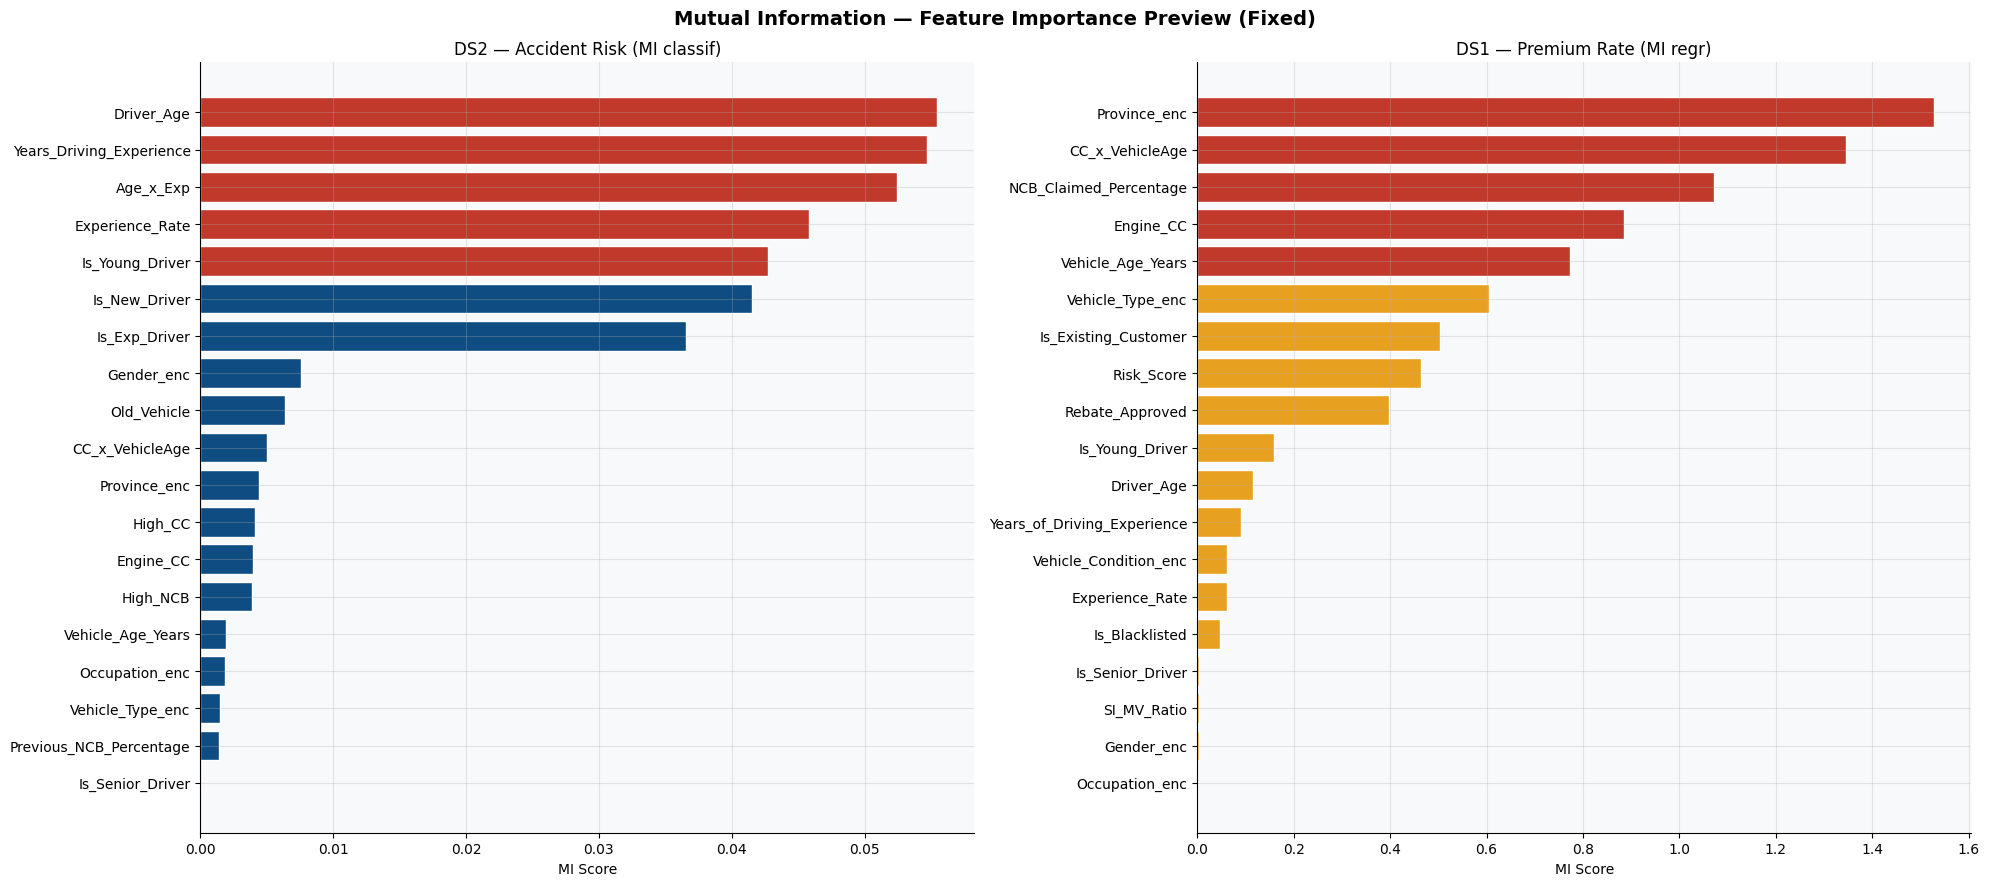

Top 5 risk features (MI): {'Driver_Age': 0.05547420081213161, 'Years_Driving_Experience': 0.05472029482130103, 'Age_x_Exp': 0.05241375408690607, 'Experience_Rate': 0.045806699891610236, 'Is_Young_Driver': 0.04270279667390153}
Top 5 rate features (MI): {'Province_enc': 1.528443187592034, 'CC_x_VehicleAge': 1.3445851891532041, 'NCB_Claimed_Percentage': 1.072218853293114, 'Engine_CC': 0.8859238202676247, 'Vehicle_Age_Years': 0.7725724062557622}

EXPECTED:
  Risk: Is_Young_Driver, Experience_Rate, Province_enc should rank top 5
  Rate: NCB, Province_enc, Vehicle_Type_enc should rank above Risk_Score
  (NOT SI or MV — those are now removed from rate features)


In [12]:

fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.suptitle('Mutual Information — Feature Importance Preview (Fixed)', fontsize=14, fontweight='bold')

mi_risk = mutual_info_classif(X_risk.fillna(0), y_risk, random_state=42)
mi_rate = mutual_info_regression(X_rate.fillna(0), y_rate, random_state=42)

for ax, mi, feats, title, color, task in [
    (axes[0], mi_risk, DS2_RISK_COLS, 'DS2 — Accident Risk (MI classif)', C[0], 'risk'),
    (axes[1], mi_rate, DS1_RATE_COLS, 'DS1 — Premium Rate (MI regr)',     C[1], 'rate'),
]:
    s = pd.Series(mi, index=feats[:len(mi)]).sort_values(ascending=True)
    bar_colors = [C[3] if v > s.quantile(0.75) else color for v in s]
    ax.barh(s.index, s.values, color=bar_colors, edgecolor='white')
    ax.set_title(title); ax.set_xlabel('MI Score')

plt.tight_layout()
plt.savefig('fig_05_mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 risk features (MI):", pd.Series(mi_risk, index=DS2_RISK_COLS).nlargest(5).to_dict())
print("Top 5 rate features (MI):", pd.Series(mi_rate, index=DS1_RATE_COLS).nlargest(5).to_dict())
print()
print("EXPECTED:")
print("  Risk: Is_Young_Driver, Experience_Rate, Province_enc should rank top 5")
print("  Rate: NCB, Province_enc, Vehicle_Type_enc should rank above Risk_Score")
print("  (NOT SI or MV — those are now removed from rate features)")
